In [4]:
import keras

In [5]:
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


In [7]:
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


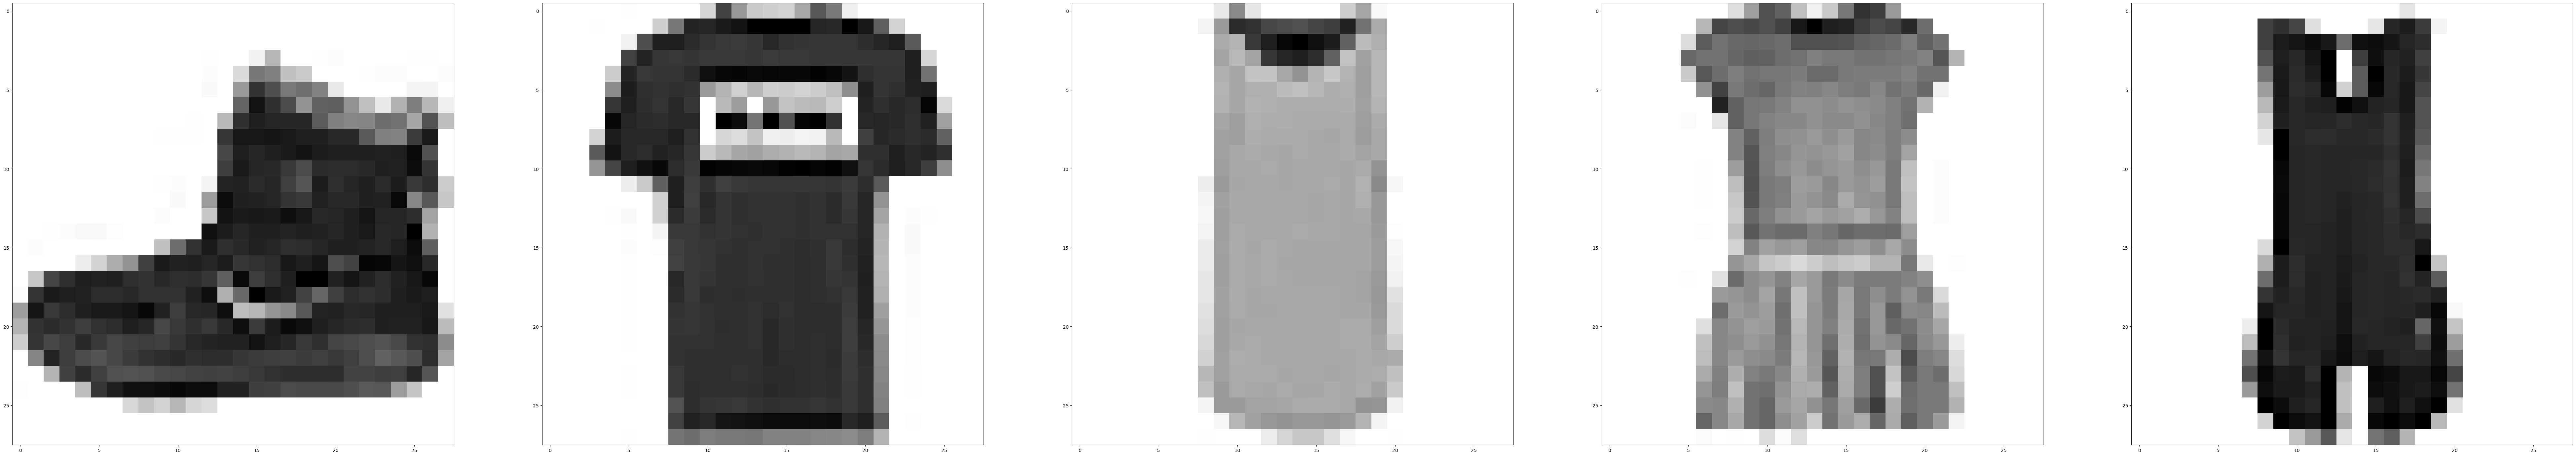

In [13]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 5, figsize=(100,100))
for i in range(0, 5):
    axs[i].imshow(train_input[i], cmap='grey_r')
    axs[i].axis=('off')
plt.show()

In [18]:
import numpy as np
np.unique(train_target, return_counts=True)


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [19]:
train_scaled = train_input/255
train_scaled = train_scaled.reshape(-1, 28*28)

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', max_iter=5, random_state=42)
# max_iter 은 SGDC를 최대 몇 번이나 반복할 것인가? 
scores = cross_validate(sc, train_scaled, train_target, return_train_score=True, n_jobs=-1)

{'fit_time': array([8.52078867, 8.54090118, 8.09593964, 8.21896267, 7.72159219]),
 'score_time': array([0.02480745, 0.03518963, 0.04890299, 0.0443368 , 0.03976679]),
 'test_score': array([0.83      , 0.81991667, 0.82008333, 0.80766667, 0.81958333]),
 'train_score': array([0.8395625 , 0.83760417, 0.8303125 , 0.81741667, 0.831125  ])}

In [23]:
print(np.mean(scores['test_score']))

0.81945


In [25]:
import tensorflow as tf

In [26]:
import keras

In [29]:
keras.config.backend()

'tensorflow'

In [ ]:
from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, random_state=42, test_size=0.2)
# 이런 식으로 기존 train_scaled를 다시 train_scaled와 val로 나누었다.

In [33]:
val_scaled.shape

(12000, 784)

In [ ]:
inputs = keras.layers.Input(shape=(784,))

In [35]:
dense = keras.layers.Dense(10, activation='softmax')

In [36]:
model = keras.Sequential([inputs, dense])

In [ ]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(train_scaled, train_target, epochs=10, Earl)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8577 - loss: 0.4228
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8578 - loss: 0.4188
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8603 - loss: 0.4145
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8613 - loss: 0.4122
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8612 - loss: 0.4092
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8634 - loss: 0.4074
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8645 - loss: 0.4057
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8641 - loss: 0.4042
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8644 - loss: 0.4029
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8648 - loss: 0.4009


In [41]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8493 - loss: 0.4460


[0.44595035910606384, 0.8493333458900452]